In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

In [2]:
sa = pd.read_csv(r"C:\Users\YASH\OneDrive\Desktop\OIBSIP\Reviews.csv")
sa.head(2)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...


In [3]:
print("Number of rows:", sa.shape[0])
print("Number of columns:", sa.shape[1])

Number of rows: 568454
Number of columns: 10


In [4]:
# Missing values
missing_values = sa.isnull().sum()
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': (
        missing_values / len(sa) * 100
    ).round(2)
})

display(missing_summary)

,Missing Values,Missing Percentage
Id,0,0.0
ProductId,0,0.0
UserId,0,0.0
ProfileName,26,0.0
HelpfulnessNumerator,0,0.0
HelpfulnessDenominator,0,0.0
Score,0,0.0
Time,0,0.0
Summary,27,0.0
Text,0,0.0


In [5]:
# Select Required col
sa = sa[['Text', 'Score']].copy()
print("Selected columns:")
print(sa.columns.tolist())
display(sa.head())

Selected columns:
['Text', 'Score']


,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [7]:
# There are no missing values in dataset

In [8]:
def create_sentiment(score):
    if score <= 2:
        return 'Negative'
    
    elif score == 3:
        return 'Neutral'
    
    else:
        return 'Positive'

sa['Sentiment'] = sa['Score'].apply(create_sentiment)
display(sa.head())

,Text,Score,Sentiment
0,I have bought several of the Vitality canned d...,5,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,Negative
2,This is a confection that has been around a fe...,4,Positive
3,If you are looking for the secret ingredient i...,2,Negative
4,Great taffy at a great price. There was a wid...,5,Positive


In [9]:
sentiment_counts = sa['Sentiment'].value_counts()
print("Sentiment Distribution:")
print(sentiment_counts)

Sentiment Distribution:
Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


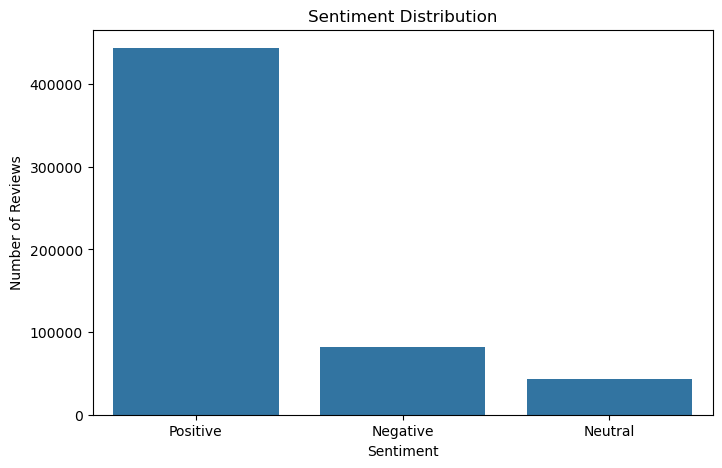

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=sa,
    x='Sentiment'
)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

## Sentiment Distribution Observation

The dataset contains three sentiment categories: Positive, Neutral, and Negative.

The distribution shows how customer reviews are distributed across different sentiment classes. Class imbalance is important because a model may perform well on the majority class while performing poorly on underrepresented classes.

In [11]:
def clean_text(text):  
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [12]:
sa['Clean_Text'] = sa['Text'].apply(clean_text)
display(sa[['Text', 'Clean_Text', 'Sentiment']].head(10))

,Text,Clean_Text,Sentiment
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...,Negative
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...,Positive
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,Negative
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...,Positive
5,I got a wild hair for taffy and ordered this f...,i got a wild hair for taffy and ordered this f...,Positive
6,This saltwater taffy had great flavors and was...,this saltwater taffy had great flavors and was...,Positive
7,This taffy is so good. It is very soft and ch...,this taffy is so good it is very soft and chew...,Positive
8,Right now I'm mostly just sprouting this so my...,right now im mostly just sprouting this so my ...,Positive
9,This is a very healthy dog food. Good for thei...,this is a very healthy dog food good for their...,Positive


In [13]:
sa = sa[sa['Clean_Text'].str.len() > 0]
print("Dataset shape after text cleaning:", sa.shape)

Dataset shape after text cleaning: (568439, 4)


In [14]:
# Reduce Dataset Size for Faster Processing
sample_size = 30000
sa_sample = (
    sa.groupby('Sentiment', group_keys=False)
      .apply(
          lambda x: x.sample(
              min(len(x), sample_size // 3),
              random_state=42
          )
      )
      .reset_index(drop=True)
)

print("Sampled dataset shape:", sa_sample.shape)
print("\nSentiment distribution:")
print(sa_sample['Sentiment'].value_counts())

Sampled dataset shape: (30000, 4)

Sentiment distribution:
Sentiment
Negative    10000
Neutral     10000
Positive    10000
Name: count, dtype: int64


In [15]:
X = sa_sample['Clean_Text']
y = sa_sample['Sentiment']
print("Features prepared successfully!")
print("Number of reviews:", len(X))
print("Number of sentiment labels:", len(y))

Features prepared successfully!
Number of reviews: 30000
Number of sentiment labels: 30000


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24000
Testing samples: 6000


In [17]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF vectorization completed!")
print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

TF-IDF vectorization completed!
Training matrix shape: (24000, 10000)
Testing matrix shape: (6000, 10000)


## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that machine learning models can understand.

It gives higher importance to words that are frequent in a particular review but less common across the entire collection of reviews.

Bigrams were also included to capture short phrases such as "very good" and "not recommended".

In [18]:
# Train Naives Bayes
nb_model = MultinomialNB()
nb_model.fit(
    X_train_tfidf,
    y_train
)
nb_predictions = nb_model.predict(X_test_tfidf)
print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [19]:
# Evaluate Naive Bayes
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average='weighted'
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average='weighted'
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average='weighted'
)
print("NAIVE BAYES RESULTS")
print("--------------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))

NAIVE BAYES RESULTS
--------------------------
Accuracy : 0.6743
Precision: 0.6758
Recall   : 0.6743
F1 Score : 0.675


In [20]:
# classification report
print(
    classification_report(
        y_test,
        nb_predictions
    )
)

              precision    recall  f1-score   support

    Negative       0.70      0.68      0.69      2000
     Neutral       0.58      0.59      0.58      2000
    Positive       0.75      0.75      0.75      2000

    accuracy                           0.67      6000
   macro avg       0.68      0.67      0.67      6000
weighted avg       0.68      0.67      0.67      6000



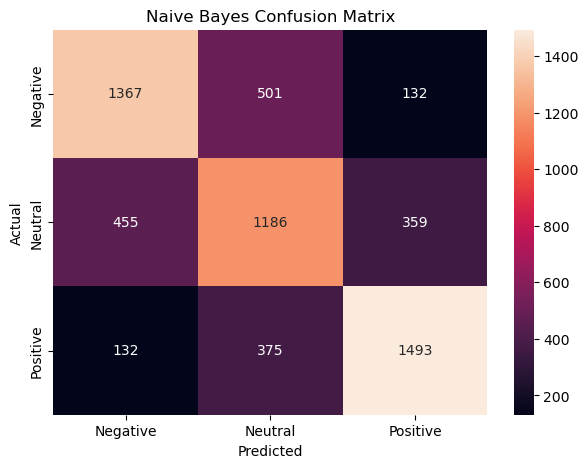

In [21]:
nb_cm = confusion_matrix(
    y_test,
    nb_predictions,
    labels=['Negative', 'Neutral', 'Positive']
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    nb_cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(
    X_train_tfidf,
    y_train
)
lr_predictions = lr_model.predict(X_test_tfidf)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [23]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision = precision_score(
    y_test,
    lr_predictions,
    average='weighted'
)

lr_recall = recall_score(
    y_test,
    lr_predictions,
    average='weighted'
)

lr_f1 = f1_score(
    y_test,
    lr_predictions,
    average='weighted'
)
print("LOGISTIC REGRESSION RESULTS")
print("--------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

LOGISTIC REGRESSION RESULTS
--------------------------
Accuracy : 0.6978
Precision: 0.6967
Recall   : 0.6978
F1 Score : 0.6972


In [24]:
print(
    classification_report(
        y_test,
        lr_predictions
    )
)

              precision    recall  f1-score   support

    Negative       0.71      0.71      0.71      2000
     Neutral       0.62      0.60      0.61      2000
    Positive       0.76      0.78      0.77      2000

    accuracy                           0.70      6000
   macro avg       0.70      0.70      0.70      6000
weighted avg       0.70      0.70      0.70      6000



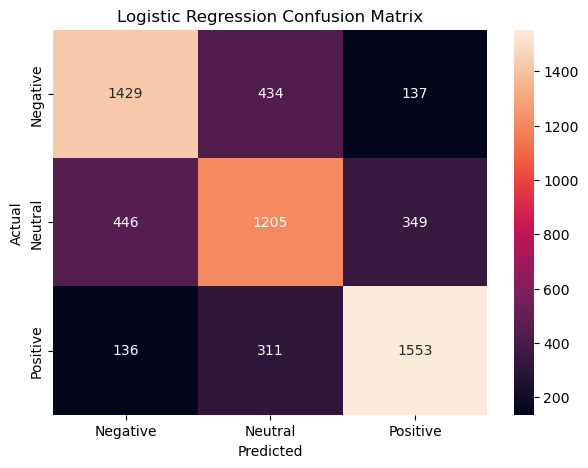

In [25]:
lr_cm = confusion_matrix(
    y_test,
    lr_predictions,
    labels=['Negative', 'Neutral', 'Positive']
)
plt.figure(figsize=(7, 5))
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
model_comparison = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression'
    ],
    
    'Accuracy': [
        nb_accuracy,
        lr_accuracy
    ],
    
    'Precision': [
        nb_precision,
        lr_precision
    ],
    
    'Recall': [
        nb_recall,
        lr_recall
    ],
    
    'F1 Score': [
        nb_f1,
        lr_f1
    ]
})
display(
    model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.6743,0.6758,0.6743,0.6750
1,Logistic Regression,0.6978,0.6967,0.6978,0.6972


In [27]:
best_model = model_comparison.loc[
    model_comparison['F1 Score'].idxmax()
]
print("BEST PERFORMING MODEL")
print("--------------------------")
print("Model:", best_model['Model'])
print("Accuracy:", round(best_model['Accuracy'], 4))
print("Precision:", round(best_model['Precision'], 4))
print("Recall:", round(best_model['Recall'], 4))
print("F1 Score:", round(best_model['F1 Score'], 4))

BEST PERFORMING MODEL
--------------------------
Model: Logistic Regression
Accuracy: 0.6978
Precision: 0.6967
Recall: 0.6978
F1 Score: 0.6972


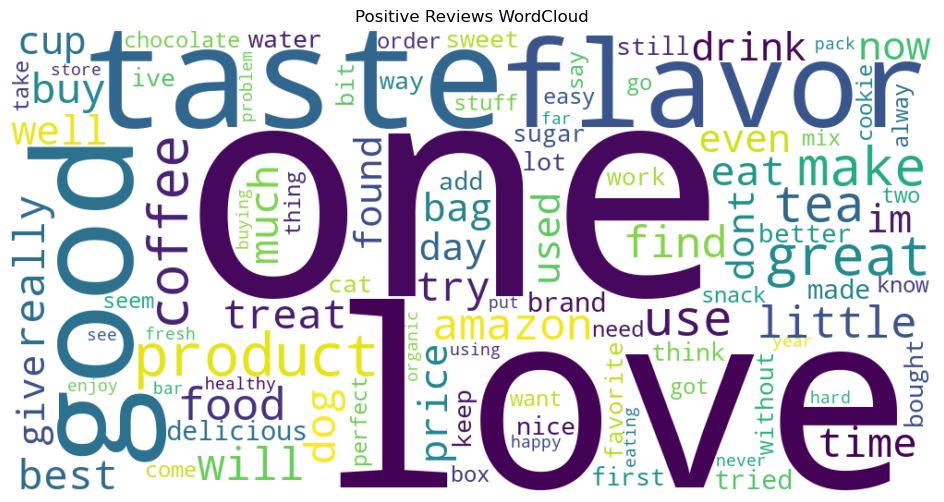

In [28]:
positive_text = ' '.join(
    sa_sample[
        sa_sample['Sentiment'] == 'Positive'
    ]['Clean_Text']
)
positive_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(positive_text)
plt.figure(figsize=(12, 6))
plt.imshow(
    positive_wordcloud,
    interpolation='bilinear'
)
plt.axis('off')
plt.title('Positive Reviews WordCloud')
plt.show()

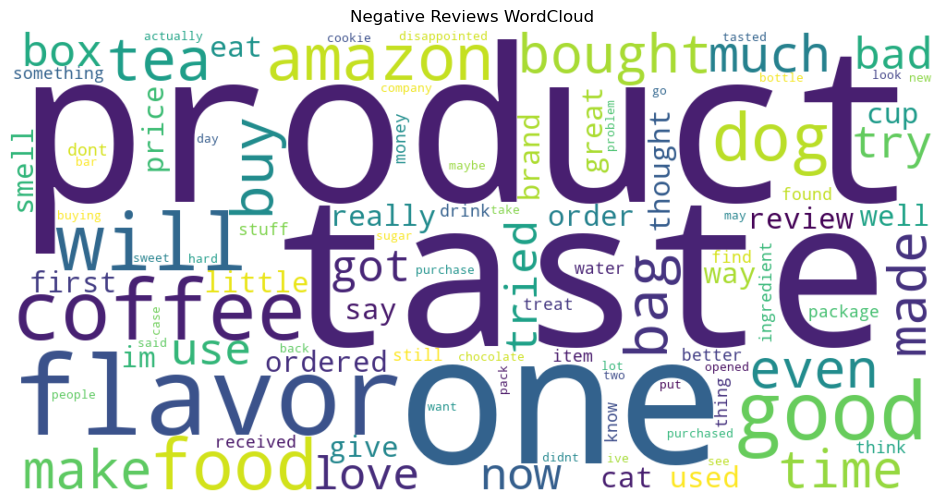

In [30]:
negative_text = ' '.join(
    sa_sample[
        sa_sample['Sentiment'] == 'Negative'
    ]['Clean_Text']
)
negative_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(negative_text)
plt.figure(figsize=(12, 6))
plt.imshow(
    negative_wordcloud,
    interpolation='bilinear'
)
plt.axis('off')
plt.title('Negative Reviews WordCloud')
plt.show()

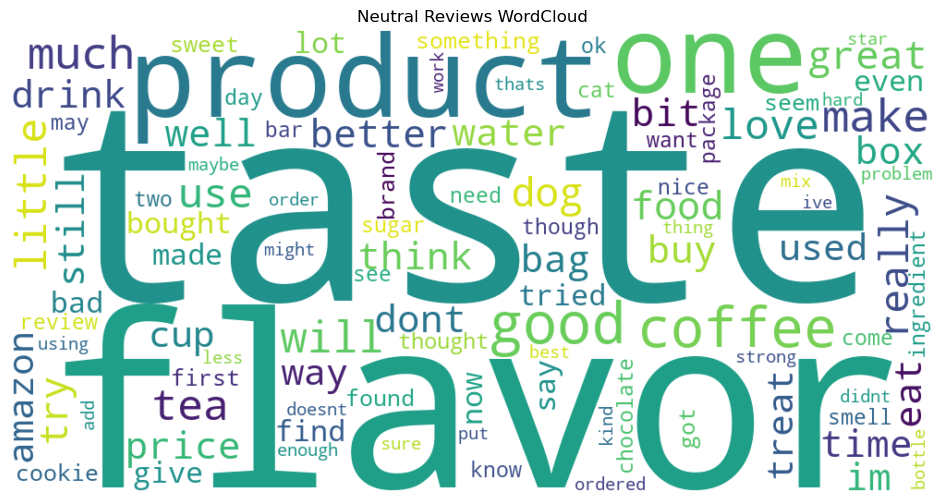

In [31]:
neutral_text = ' '.join(
    sa_sample[
        sa_sample['Sentiment'] == 'Neutral'
    ]['Clean_Text']
)
neutral_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(neutral_text)
plt.figure(figsize=(12, 6))
plt.imshow(
    neutral_wordcloud,
    interpolation='bilinear'
)
plt.axis('off')
plt.title('Neutral Reviews WordCloud')
plt.show()

In [32]:
if best_model['Model'] == 'Naive Bayes':
    final_predictions = nb_predictions
else:
    final_predictions = lr_predictions
error_analysis = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': final_predictions,
    'Review': X_test.values
})
errors = error_analysis[
    error_analysis['Actual'] != error_analysis['Predicted']
]
print("Number of misclassified reviews:", len(errors))
display(
    errors.head(5)
)

Number of misclassified reviews: 1813


,Actual,Predicted,Review
1,Positive,Negative,i bought a case of all three products inka per...
4,Neutral,Positive,good quality product though a bit pricey taste...
6,Neutral,Positive,the price just increased by about for kcups wh...
12,Negative,Positive,i have tried a lot of other simply organic pro...
13,Neutral,Positive,i love this bread the shelf life is not always...


In [33]:
print("FIVE MISCLASSIFIED REVIEWS")
print("=" * 80)

for i, row in errors.head(5).iterrows():
    
    print("\nActual Sentiment:", row['Actual'])
    print("Predicted Sentiment:", row['Predicted'])
    print("Review:")
    print(row['Review'])
    print("-" * 80)

FIVE MISCLASSIFIED REVIEWS

Actual Sentiment: Positive
Predicted Sentiment: Negative
Review:
i bought a case of all three products inka pero and cafix in order to compare them honestly they are all the same so go with whatever is the cheapest i think i did like cafix the best but it may be a mental thing with the name at least sounding somewhat like coffee there is little difference in all three they look identical with only tiny coloration differences all by themselves they do not taste like coffee and if you are a black coffee drinker pass because you will not be satisfied with the taste it is very bland all by itself but if you like cream in your coffee you wont even notice the difference between coffee and these products within a week or two you will forget you are not drinking coffee i am perfectly happy with all three products and will continue to drink themi will choose by price due to the very similar make of them all the cans all read the same ingredient wise
-----------------

In [34]:
sample_reviews = [
    "This product is excellent and I absolutely love it.",
    "The product was okay, nothing special.",
    "Very disappointing product and poor quality."
]
sample_cleaned = [
    clean_text(review)
    for review in sample_reviews
]
sample_tfidf = tfidf.transform(sample_cleaned)

sample_predictions = lr_model.predict(sample_tfidf)

prediction_results = pd.DataFrame({
    'Review': sample_reviews,
    'Predicted Sentiment': sample_predictions
})
display(prediction_results)

,Review,Predicted Sentiment
0,This product is excellent and I absolutely lov...,Positive
1,"The product was okay, nothing special.",Neutral
2,Very disappointing product and poor quality.,Negative


In [35]:
print("=" * 60)
print("SENTIMENT ANALYSIS PROJECT SUMMARY")
print("=" * 60)

print("\nOriginal Dataset Rows:", len(sa))

print("Sampled Dataset Rows:", len(sa_sample))

print("\nSentiment Distribution:")
print(sa_sample['Sentiment'].value_counts())

print("\nModel Performance:")
display(model_comparison.round(4))

print("\nBest Model:", best_model['Model'])
print("Best F1 Score:", round(best_model['F1 Score'], 4))

SENTIMENT ANALYSIS PROJECT SUMMARY

Original Dataset Rows: 568439
Sampled Dataset Rows: 30000

Sentiment Distribution:
Sentiment
Negative    10000
Neutral     10000
Positive    10000
Name: count, dtype: int64

Model Performance:


,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.6743,0.6758,0.6743,0.6750
1,Logistic Regression,0.6978,0.6967,0.6978,0.6972



Best Model: Logistic Regression
Best F1 Score: 0.6972


# Conclusion

The Amazon Fine Food Reviews dataset was analysed to classify customer reviews into Positive, Neutral, and Negative sentiment categories.

The text data was cleaned through lowercasing, URL removal, HTML removal, punctuation removal, number removal, and whitespace normalization.

TF-IDF was used to convert textual information into numerical features. Two machine learning models, Naive Bayes and Logistic Regression, were trained and evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.

WordCloud visualizations were used to identify frequently occurring words within positive, negative, and neutral reviews.

Error analysis was also performed by examining incorrectly classified reviews.

The model with the highest F1-score was selected as the best-performing model. This sentiment analysis system can help businesses understand customer opinions, identify negative feedback, and monitor customer satisfaction at scale.